## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [ ]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [ ]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [ ]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2010-2021.csv', encoding=enc)

In [ ]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-01,2010,1,2009-12-07,40.659996,22.397246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.659996,22.397246,14192.0,14017.0,40.659996,22.397246,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,2010-01-01,40.650186,22.350102,0.019869,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.019869,0.019869
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-16,2010,1,2009-12-07,40.659996,22.397246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,40.659996,22.397246,14129.0,13839.0,40.659996,22.397246,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,2010-01-16,40.650186,22.350102,21.994516,2010-01-09,2010-01-02,2010-01-09,2010-01-02,1.172702,21.024027
2,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-01,2010,1,2009-12-07,40.677962,22.464619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.677962,22.464619,14251.0,13995.0,40.677962,22.464619,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,2010-01-01,40.650186,22.450103,0.021185,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.021185,0.021185
3,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-16,2010,1,2009-12-07,40.677962,22.464619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,40.677962,22.464619,14188.0,13820.0,40.677962,22.464619,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,2010-01-16,40.650186,22.450103,19.148625,2010-01-09,2010-01-02,2010-01-09,2010-01-02,1.418397,18.804765
4,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2010-01-01,2010,1,2009-12-07,40.624063,22.491569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.624063,22.491569,14239.0,14024.0,40.624063,22.491569,14020.000000,13876.500000,14157.333333,13762.727273,14546.416667,13868.470588,15075.142857,14133.833333,2010-01-01,40.650186,22.450103,0.021185,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.021185,0.021185


In [ ]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-01,0
1,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-16,0
2,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-01,0
3,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-16,2
4,αλεξανδρειας,κεντρικης μακεδονιας,2010-08-01,11


In [ ]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [ ]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [ ]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [ ]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14192.0,14017.0,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,0.019869,0.019869,0.019869
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14129.0,13839.0,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,21.994516,1.172702,21.024027
2,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14251.0,13995.0,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,0.021185,0.021185,0.021185
3,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14188.0,13820.0,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,19.148625,1.418397,18.804765
4,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14239.0,14024.0,14020.000000,13876.500000,14157.333333,13762.727273,14546.416667,13868.470588,15075.142857,14133.833333,0.021185,0.021185,0.021185


In [ ]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-01,0
1,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-16,0
2,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-01,0
3,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-16,2
4,αλεξανδρειας,κεντρικης μακεδονιας,2010-08-01,11


In [ ]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


['ηρωικης πολης ναουσας']

Length: 1


In [ ]:
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολης ναουσας','ναουσας'))

In [ ]:
## Check again

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [ ]:
merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [ ]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14192.0,14017.0,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,0.019869,0.019869,0.019869,NaN
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14129.0,13839.0,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,21.994516,1.172702,21.024027,NaN
2,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14251.0,13995.0,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,0.021185,0.021185,0.021185,NaN
3,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14188.0,13820.0,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,19.148625,1.418397,18.804765,NaN
4,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14239.0,14024.0,14020.000000,13876.500000,14157.333333,13762.727273,14546.416667,13868.470588,15075.142857,14133.833333,0.021185,0.021185,0.021185,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51835,χαλκηδονος,κεντρικης μακεδονιας,22.73880,40.73560,2021-12-16,2021,12,0.251805,-0.073830,-0.213668,0.073830,0.285509,-0.033475,-0.240839,0.033475,0.049812,0.042605,0.035642,0.042605,NaN,NaN,14123.750000,13539.555556,14496.076923,13847.111111,14702.923077,13852.117647,14842.076923,14030.071429,1117.097203,59.682183,90.624163,NaN
51836,ωραιοκαστρου,κεντρικης μακεδονιας,22.94073,40.74476,2021-12-01,2021,12,0.586417,0.234927,-0.449285,-0.234927,0.449600,0.105007,-0.355143,-0.105007,0.078153,0.070156,0.061729,0.070156,NaN,NaN,14048.333333,13653.142857,14364.266667,13877.850000,14443.200000,13843.214286,14749.466667,13954.000000,1161.068238,11.701603,42.697279,NaN
51837,ωραιοκαστρου,κεντρικης μακεδονιας,22.94073,40.74476,2021-12-16,2021,12,0.586417,0.234927,-0.449285,-0.234927,0.449600,0.105007,-0.355143,-0.105007,0.078153,0.070156,0.061729,0.070156,NaN,NaN,14048.333333,13653.142857,14364.266667,13877.850000,14443.200000,13843.214286,14749.466667,13954.000000,1283.646776,62.627688,122.578538,NaN
51838,ωραιοκαστρου,κεντρικης μακεδονιας,22.94073,40.79866,2021-12-01,2021,12,0.391987,0.052467,-0.309246,-0.052467,0.333284,-0.004223,-0.285973,0.004223,0.100953,0.054073,0.055935,0.054073,NaN,NaN,13945.909091,13627.000000,14269.133333,13878.111111,14559.923077,13795.000000,14824.533333,13996.923077,1161.068238,11.701603,42.697279,NaN


In [ ]:
merged = fillna(merged,{'case': 0})

In [ ]:
merged['case'].value_counts()

0.0     50324
1.0       901
2.0       306
3.0       118
4.0        82
        ...  
8.0        10
18.0        5
12.0        5
9.0         5
11.0        4
Name: case, Length: 13, dtype: int64

In [ ]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [ ]:
dataset = grouped.mean()

In [ ]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.483978,40.644680,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.250000,13999.75,14038.416667,13841.023810,14155.566667,13756.638258,14594.434470,13873.434314,15130.728022,14121.996545,0.015560,0.015560,0.015560,0.0
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,21.940791,40.977027,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14223.727273,13957.00,13869.513312,13744.208815,13867.496753,13711.131484,14224.720029,13763.856185,14598.699282,13988.568853,0.248551,0.248551,0.248551,0.0
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.00,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000,0.0
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.982527,40.915102,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14313.500000,14075.75,14060.466667,13849.123810,14119.082323,13755.281926,14385.038636,13831.014839,14687.678342,14072.125000,0.055994,0.055994,0.055994,0.0
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.691080,40.495934,2010.0,1.0,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.000000,0.000000,0.000000,0.000000,14419.500000,14040.25,14128.136995,13903.784226,14068.485978,13793.050847,14424.248689,13827.634516,14601.602841,14032.383996,1.750566,1.750566,1.750566,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.828106,40.110264,2021.0,12.0,0.533019,0.216610,-0.406977,-0.216610,0.525750,0.209897,-0.401147,-0.209897,0.039324,0.061157,0.034067,0.061157,NaN,NaN,14131.712105,13798.223434,14309.703516,13947.082353,14391.596265,13919.650000,14628.870760,14012.311944,2180.544076,75.411011,161.899452,0.0
10940,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.388058,41.313484,2021.0,12.0,0.126568,-0.005089,-0.091934,0.005089,0.122184,0.074416,-0.090676,-0.074416,0.027041,0.050254,0.035247,0.050254,NaN,NaN,13895.539899,13525.684019,14245.385339,13792.929034,14454.229025,13724.788455,14684.146065,13885.721902,1562.784564,141.524710,215.682589,0.0
10941,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2021.0,12.0,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,997.526490,56.599638,67.029917,0.0
10942,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2021.0,12.0,0.255928,-0.052975,-0.231818,0.052975,0.276006,-0.030417,-0.240922,0.030417,0.059156,0.056067,0.041252,0.056067,NaN,NaN,14117.840476,13553.251852,14456.092308,13851.944444,14692.609280,13852.974401,14831.047863,14012.847619,1117.097203,59.682183,90.624163,0.0


In [ ]:
dataset = dataset.astype({'case': 'int'})

In [ ]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [ ]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [ ]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [ ]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [ ]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.250000,13999.75,14038.416667,13841.023810,14155.566667,13756.638258,14594.434470,13873.434314,15130.728022,14121.996545,0.015560,0.015560,0.015560,0,1,53,46.44911,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14223.727273,13957.00,13869.513312,13744.208815,13867.496753,13711.131484,14224.720029,13763.856185,14598.699282,13988.568853,0.248551,0.248551,0.248551,0,1,53,46.48134,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.00,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000,0,1,53,46.65786,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14313.500000,14075.75,14060.466667,13849.123810,14119.082323,13755.281926,14385.038636,13831.014839,14687.678342,14072.125000,0.055994,0.055994,0.055994,0,1,53,47.42581,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2010,1,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.000000,0.000000,0.000000,0.000000,14419.500000,14040.25,14128.136995,13903.784226,14068.485978,13793.050847,14424.248689,13827.634516,14601.602841,14032.383996,1.750566,1.750566,1.750566,0,1,53,46.91682,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2021,12,0.533019,0.216610,-0.406977,-0.216610,0.525750,0.209897,-0.401147,-0.209897,0.039324,0.061157,0.034067,0.061157,NaN,NaN,14131.712105,13798.223434,14309.703516,13947.082353,14391.596265,13919.650000,14628.870760,14012.311944,2180.544076,75.411011,161.899452,0,16,50,46.65417,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
10940,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2021,12,0.126568,-0.005089,-0.091934,0.005089,0.122184,0.074416,-0.090676,-0.074416,0.027041,0.050254,0.035247,0.050254,NaN,NaN,13895.539899,13525.684019,14245.385339,13792.929034,14454.229025,13724.788455,14684.146065,13885.721902,1562.784564,141.524710,215.682589,0,16,50,47.47426,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
10941,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2021,12,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,997.526490,56.599638,67.029917,0,16,50,46.44339,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
10942,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2021,12,0.255928,-0.052975,-0.231818,0.052975,0.276006,-0.030417,-0.240922,0.030417,0.059156,0.056067,0.041252,0.056067,NaN,NaN,14117.840476,13553.251852,14456.092308,13851.944444,14692.609280,13852.974401,14831.047863,14012.847619,1117.097203,59.682183,90.624163,0,16,50,46.66

<AxesSubplot:>

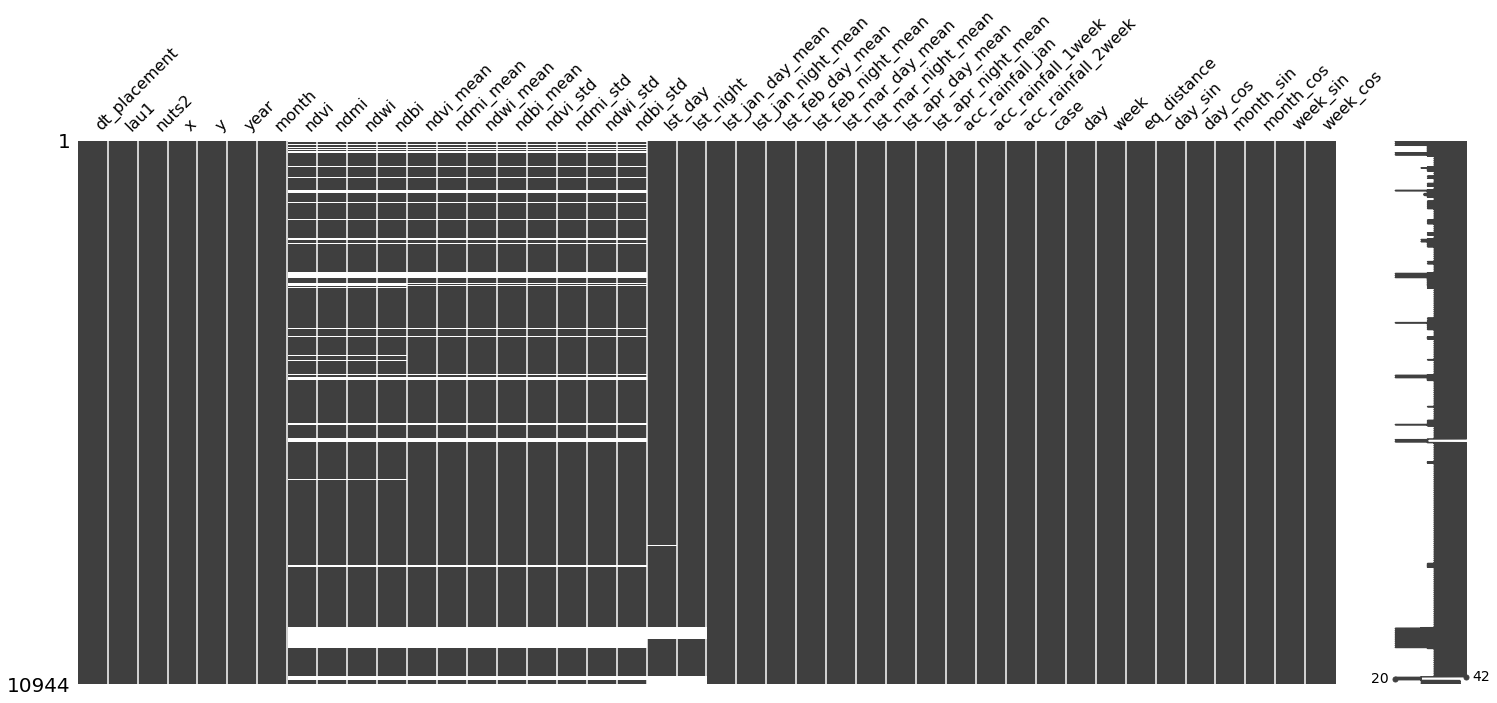

In [ ]:
missingno.matrix(dataset)

In [ ]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [ ]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [ ]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [ ]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [ ]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αλεξανδρειας,478.8,86.8,38293.0
1,αλμωπιας,985.8,28.0,24924.0
2,αμπελοκηπων μενεμενης,9.8,5319.1,49674.0
3,αμφιπολης,411.8,22.3,7169.0
4,αριστοτελη,747.0,24.5,16994.0
...,...,...,...,...
33,σιθωνιας,516.8,24.0,11631.0
34,σιντικης,1103.4,20.1,18532.0
35,σκυδρας,239.5,84.3,18080.0
36,χαλκηδονος,391.5,86.0,29951.0


In [ ]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['ναουσας']

Length: 1


In [ ]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [ ]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [ ]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

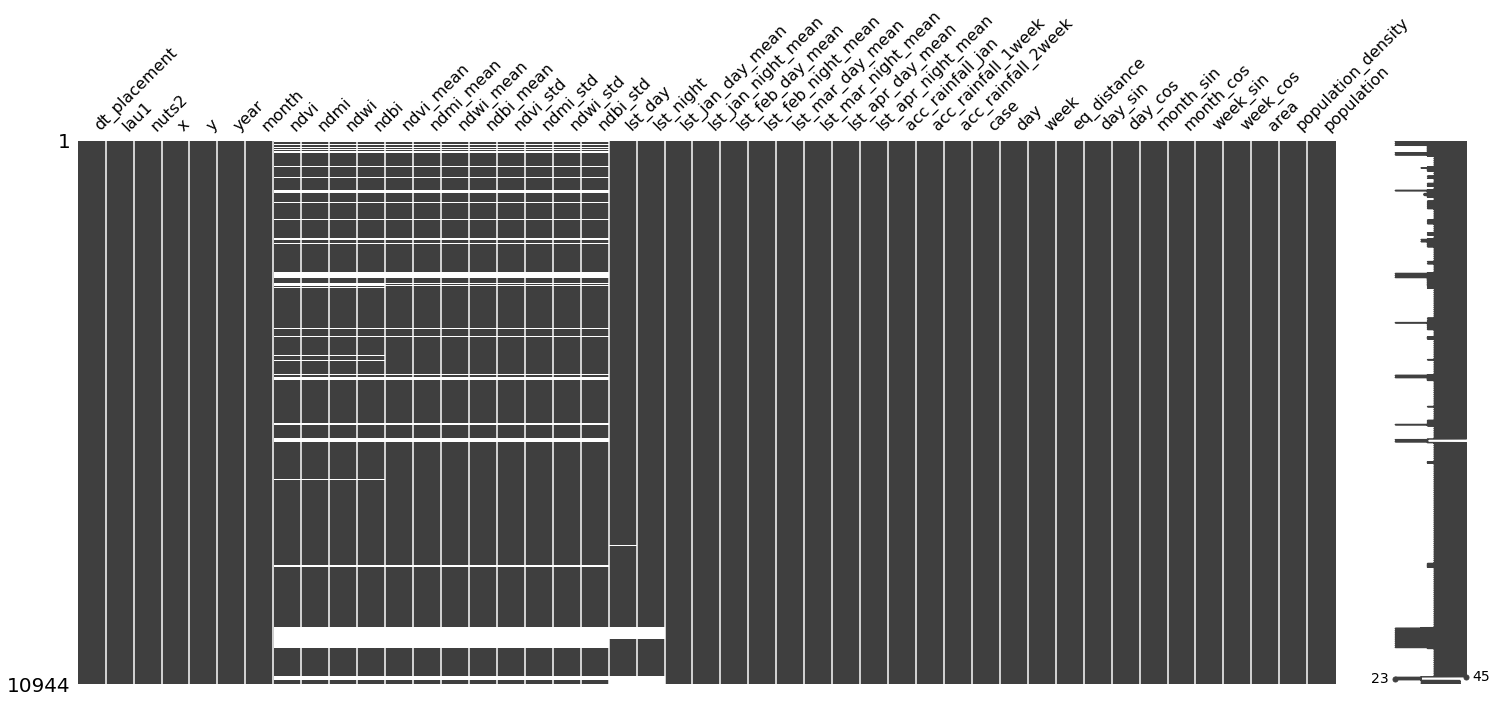

In [ ]:
missingno.matrix(dataset)

In [ ]:
missing = describe_dataframe(dataset)

In [ ]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.250000,13999.75,14038.416667,13841.023810,14155.566667,13756.638258,14594.434470,13873.434314,15130.728022,14121.996545,0.015560,0.015560,0.015560,0,1,53,46.44911,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,478.8,86.8,38293.0
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14223.727273,13957.00,13869.513312,13744.208815,13867.496753,13711.131484,14224.720029,13763.856185,14598.699282,13988.568853,0.248551,0.248551,0.248551,0,1,53,46.48134,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,985.8,28.0,24924.0
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.00,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000,0,1,53,46.65786,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,9.8,5319.1,49674.0
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14313.500000,14075.75,14060.466667,13849.123810,14119.082323,13755.281926,14385.038636,13831.014839,14687.678342,14072.125000,0.055994,0.055994,0.055994,0,1,53,47.42581,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,411.8,22.3,7169.0
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2010,1,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.000000,0.000000,0.000000,0.000000,14419.500000,14040.25,14128.136995,13903.784226,14068.485978,13793.050847,14424.248689,13827.634516,14601.602841,14032.383996,1.750566,1.750566,1.750566,0,1,53,46.91682,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,747.0,24.5,16994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2021,12,0.533019,0.216610,-0.406977,-0.216610,0.525750,0.209897,-0.401147,-0.209897,0.039324,0.061157,0.034067,0.061157,NaN,NaN,14131.712105,13798.223434,14309.703516,13947.082353,14391.596265,13919.650000,14628.870760,14012.311944,2180.544076,75.411011,161.899452,0,16,50,46.65417,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,516.8,24.0,11631.0
10940,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2021,12,0.126568,-0.005089,-0.091934,0.005089,0.122184,0.074416,-0.090676,-0.074416,0.027041,0.050254,0.035247,0.050254,NaN,NaN,13895.539899,13525.684019,14245.385339,13792.929034,14454.229025,13724.788455,14684.146065,13885.721902,1562.784564,141.524710,215.682589,0,16,50,47.47426,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,1103.4,20.1,18532.0
10941,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2021,12,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,997.526490,56.599638,67.029917,0,16,50,46.44339,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,239.5,84.3,18080.0
10942,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2021,12,0.255928,-0.052975,-0.231818,0.052975,0.276006,-0.030417,-0.240922,0.0

In [ ]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2021.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,22.483978,40.644680,2010-01-01,5
1,21.940791,40.977027,2010-01-01,2
2,22.891980,40.656030,2010-01-01,7
3,23.982527,40.915103,2010-01-01,1
4,23.691080,40.495934,2010-01-01,4
...,...,...,...,...
10939,23.828106,40.110264,2021-12-16,2
10940,23.388058,41.313484,2021-12-16,1
10941,22.146700,40.822940,2021-12-16,1
10942,22.723020,40.753567,2021-12-16,1


In [ ]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [ ]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [ ]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0011119492658909769


In [ ]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [ ]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [ ]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [ ]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.250000,13999.75,14038.416667,13841.023810,14155.566667,13756.638258,14594.434470,13873.434314,15130.728022,14121.996545,0.015560,0.015560,0.015560,0,1,53,46.44911,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,86.8,38293.0,5
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14223.727273,13957.00,13869.513312,13744.208815,13867.496753,13711.131484,14224.720029,13763.856185,14598.699282,13988.568853,0.248551,0.248551,0.248551,0,1,53,46.48134,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,28.0,24924.0,1
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.00,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000,0,1,53,46.65786,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,5319.1,49674.0,7
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14313.500000,14075.75,14060.466667,13849.123810,14119.082323,13755.281926,14385.038636,13831.014839,14687.678342,14072.125000,0.055994,0.055994,0.055994,0,1,53,47.42581,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,22.3,7169.0,20
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2010,1,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.0,0.0,0.0,0.0,14419.500000,14040.25,14128.136995,13903.784226,14068.485978,13793.050847,14424.248689,13827.634516,14601.602841,14032.383996,1.750566,1.750566,1.750566,0,1,53,46.91682,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,24.5,16994.0,4


<AxesSubplot:>

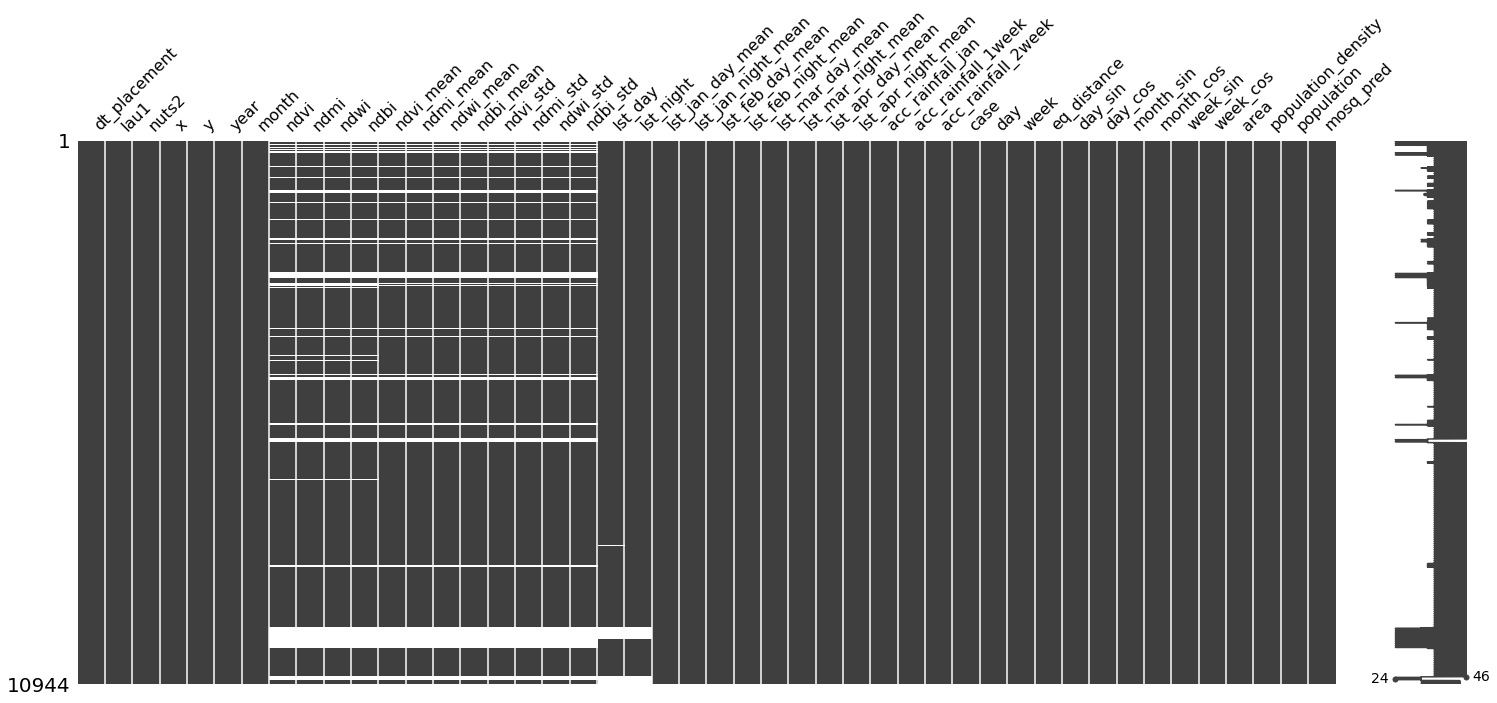

In [ ]:
missingno.matrix(dataset)

In [ ]:
dataset.reset_index(inplace=True, drop=True)

In [ ]:
dataset = calculate_mosq_previous(dataset)

In [ ]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

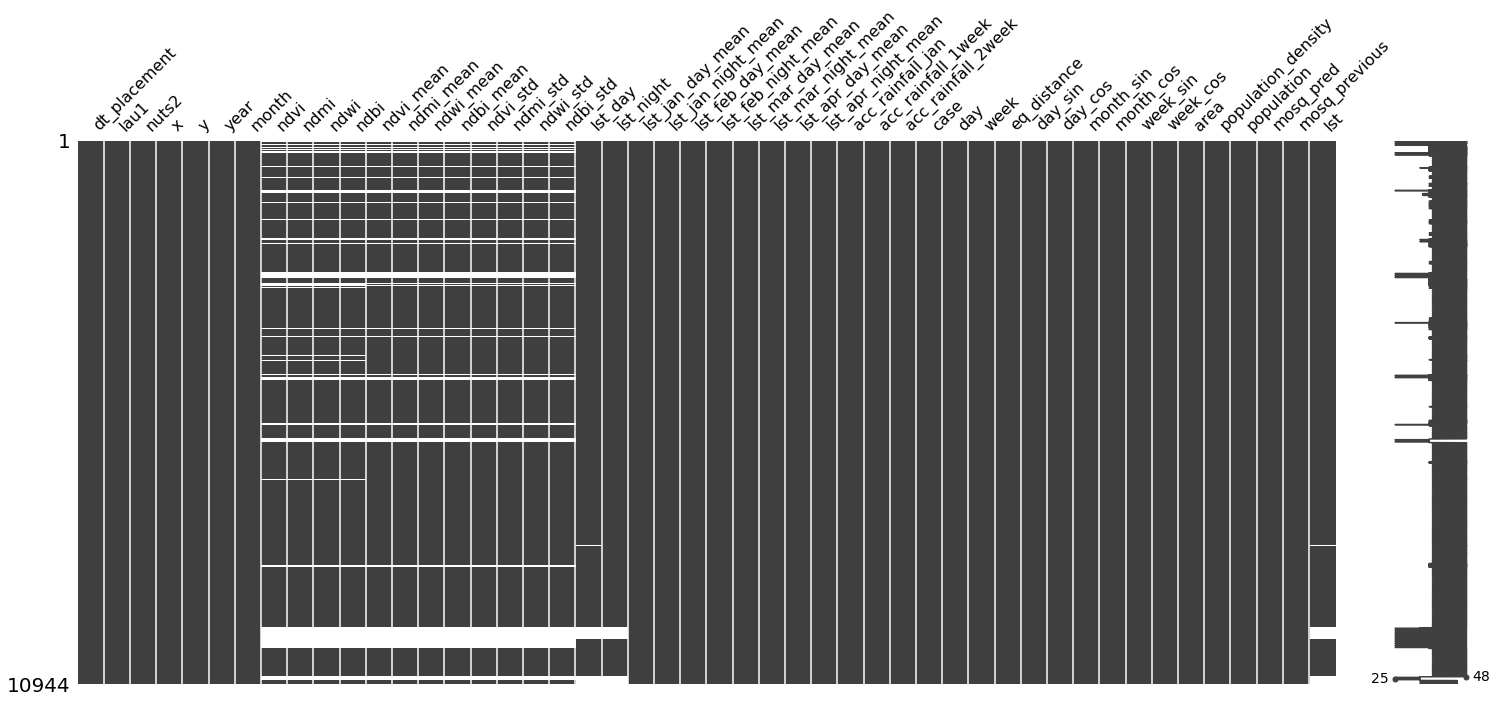

In [ ]:
missingno.matrix(dataset)

In [ ]:
dataset['case'].value_counts()

0     10608
1       212
2        61
3        23
4        20
      ...  
6         2
11        1
18        1
12        1
9         1
Name: case, Length: 13, dtype: int64

In [ ]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [ ]:
dataset = convert_multiple_cases(dataset)

In [ ]:
dataset['case'].value_counts()

0    10608
1      632
Name: case, dtype: int64

In [ ]:
cols = dataset.columns

In [ ]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [ ]:
len(cols)

48

In [ ]:
# check columns

In [ ]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [ ]:
len(final_columns)

48

In [ ]:
dataset_final = dataset[final_columns].copy()

In [ ]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.390000,11.935000,6.845,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.015560,0.015560,0.015560,5,0,0
1,21.94079,40.97703,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.657273,11.324545,5.990,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,0.248551,0.248551,0.248551,1,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,7,0,0
3,23.98253,40.91510,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.742500,13.120000,8.365,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,0.055994,0.055994,0.055994,20,0,0
4,23.69108,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,747.0,16994.0,24.5,46.91682,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.000000,0.000000,0.000000,0.000000,11.447500,15.240000,7.655,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,1.750566,1.750566,1.750566,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11235,22.41285,40.81412,2018-08-16,κεντρικης μακεδονιας,πελλας,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.56316,0.458799,0.094423,-0.417326,-0.094423,0.425498,0.082706,-0.393120,-0.082706,0.108684,0.072249,0.084478,0.072249,27.882000,34.258000,21.506,11.166473,0.115267,14.108900,1.406167,20.498747,6.152633,28.072005,12.348017,0.498782,9.606998,761.377052,4,8,1
11236,22.41285,40.81412,2018-08-16,κεντρικης μακεδονιας,πελλας,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.56316,0.458799,0.094423,-0.417326,-0.094423,0.425498,0.082706,-0.393120,-0.082706,0.108684,0.072249,0.084478,0.072249,27.882000,34.258000,21.506,11.166473,0.115267,14.108900,1.406167,20.498747,6.152633,28.072005,12.348017,0.498782,9.606998,761.377052,4,8,1
11237,22.41285,40.81412,2018-08-16,κεντρικης μακεδονιας,πελλας,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.56316,0.458799,0.094423,-0.417326,-0.094423,0.425498,0.082706,-0.393120,-0.082706,0.108684,0.072249,0.084478,0.072249,27.882000,34.258000,21.506,11.166473,0.115267,14.108900,1.406167,20.498747,6.152633,28.072005,12.348017,0.498782,9.606998,761.377052,4,8,1
11238,22.41285,40.81412,2018-08-16,κεντρικης μακεδονιας,πελλας,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.56316,0.458799,0.094423,-0.417326,-0.094423,0.425498,0.082706,-0.393120,-0.082706,0.108684,0.072249,0.

In [ ]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [3]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)


In [4]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01,2010,1,2009-12-07,39.662866,22.635299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.662866,22.635299,14407.0,14025.0,39.662866,22.635299,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,2010-01-01,39.650181,22.650104,0.000441,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000441,0.000441
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-16,2010,1,2009-12-07,39.662866,22.635299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,39.662866,22.635299,14295.0,13485.0,39.662866,22.635299,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,2010-01-16,39.650181,22.650104,18.932700,2010-01-09,2010-01-02,2010-01-09,2010-01-02,13.140626,18.916778
2,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-01,2010,1,2009-12-07,39.752697,22.707165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.752697,22.707165,14367.0,NaN,39.752697,22.707165,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,2010-01-01,39.750182,22.750104,0.030362,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.030362,0.030362
3,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-16,2010,1,2009-12-07,39.752697,22.707165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,39.752697,22.707165,14093.0,13628.0,39.752697,22.707165,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,2010-01-16,39.750182,22.750104,50.056047,2010-01-09,2010-01-02,2010-01-09,2010-01-02,33.498169,49.542448
4,αγιας,θεσσαλιας,22.73031,39.79054,2010-01-01,2010,1,2009-12-07,39.788630,22.729622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.788630,22.729622,14227.0,NaN,39.788630,22.729622,13896.166667,13803.75,13802.111111,13714.000000,14134.000000,13810.285714,14421.769231,13843.333333,2010-01-01,39.750182,22.750104,0.030362,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.030362,0.030362


In [5]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [6]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [7]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [8]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14407.0,14025.0,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,0.000441,0.000441,0.000441
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14295.0,13485.0,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,18.932700,13.140626,18.916778
2,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14367.0,NaN,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,0.030362,0.030362,0.030362
3,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14093.0,13628.0,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,50.056047,33.498169,49.542448
4,αγιας,θεσσαλιας,22.73031,39.79054,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14227.0,NaN,13896.166667,13803.75,13802.111111,13714.000000,14134.000000,13810.285714,14421.769231,13843.333333,0.030362,0.030362,0.030362


In [9]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2010-01-01,αγιας,θεσσαλιας,22.750267,39.710970,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.714286,14043.0,14144.784184,13859.708503,14085.070635,13813.365812,14450.201092,13902.285681,14604.807569,13996.636316,0.018327,0.018327,0.018327
1,2010-01-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14511.777778,14227.0,14186.415300,13889.104417,14237.209041,13872.420226,14562.648962,13970.509532,14710.665664,14064.744390,0.210382,0.210382,0.210382
2,2010-01-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14548.000000,14276.0,14251.272727,14165.875000,14178.833333,14059.285714,14412.266667,14153.944444,14600.080000,14184.529412,0.000000,0.000000,0.000000
3,2010-01-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13671.244444,13673.444444,13853.958333,13610.345238,14256.170635,13799.499573,14494.970238,13979.482143,49.209201,49.209201,49.209201
4,2010-01-01,βολου,θεσσαλιας,22.883800,39.351977,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14576.666667,NaN,14359.732143,13897.046296,14340.338384,13871.508929,14628.190476,13984.622938,14876.861477,14096.591800,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.553160,39.852112,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13933.387063,13681.367460,14200.925735,13893.654484,14283.901681,13796.241007,14616.180112,13932.598700,1202.290178,58.108282,87.904479
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.797560,39.635058,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.314423,13697.631349,14358.253773,13912.150104,14537.978095,13803.803680,14827.634685,14005.430544,1617.381678,66.377516,128.112311
7197,2021-12-16,τυρναβου,θεσσαλιας,22.343000,39.828472,2021.0,12.0,0.410104,0.187286,-0.272235,-0.187286,0.393206,0.184501,-0.26368,-0.184501,0.029704,0.058359,0.030164,0.058359,NaN,NaN,14036.815476,13722.609091,14303.707292,13897.720588,14491.201157,13824.337912,14753.932767,13972.226103,1244.257719,48.910871,86.194025
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.080342,13727.400000,14363.222278,13913.152256,14569.512821,13860.088889,14810.315873,14057.720044,1441.876840,55.608775,115.182489


In [10]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [11]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [12]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [13]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [14]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [15]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [16]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [17]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


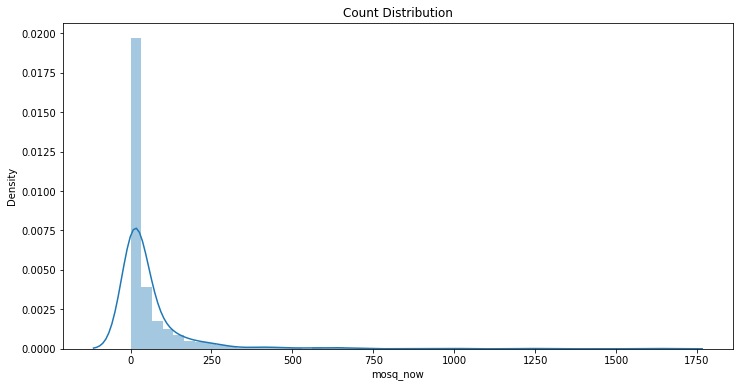

In [18]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [19]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_2784/187358562.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


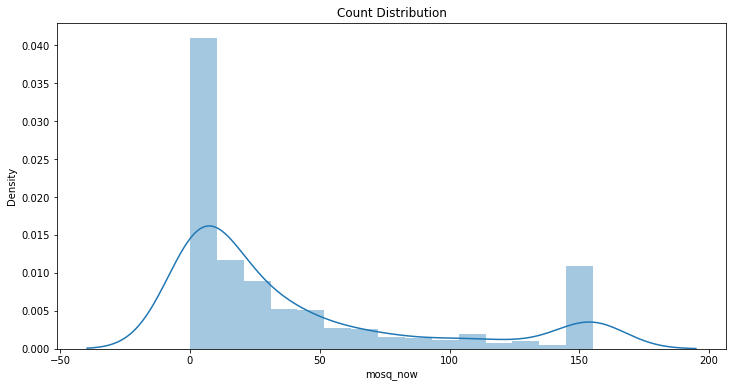

In [20]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

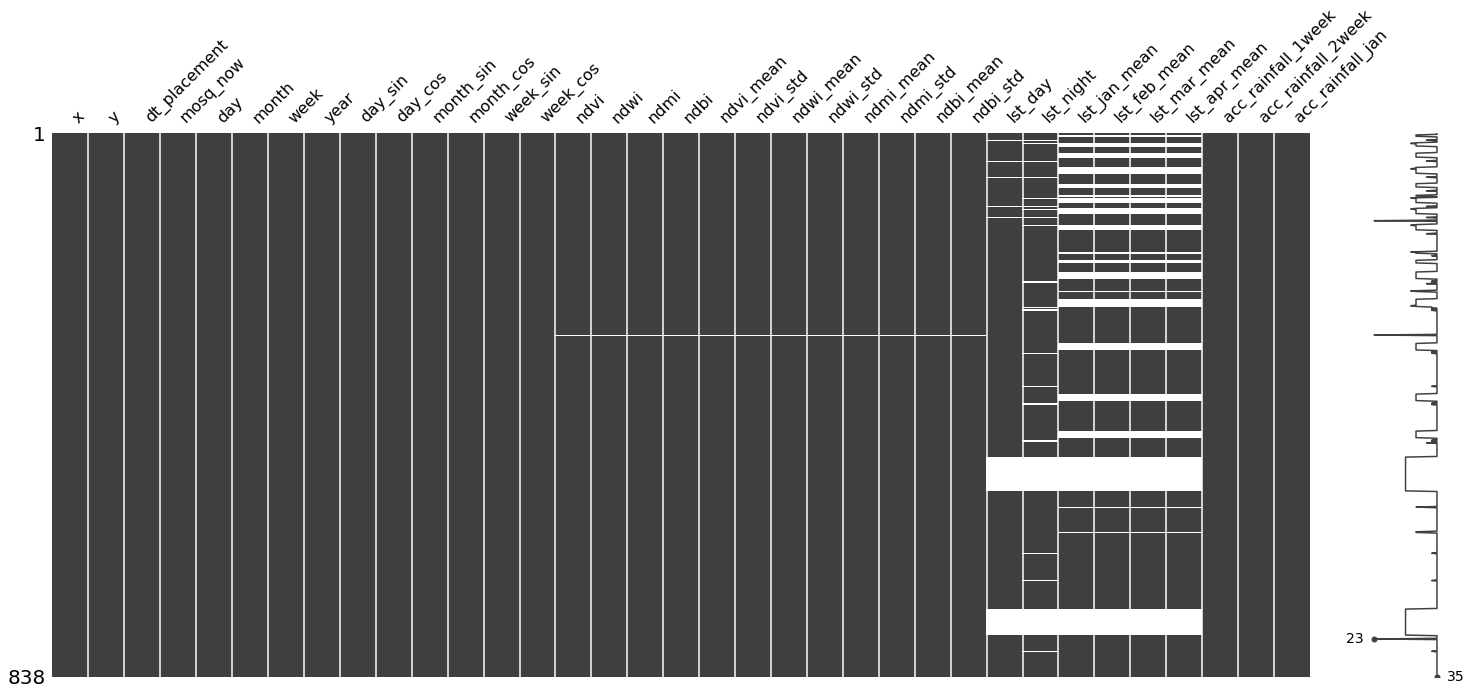

In [21]:
missingno.matrix(mosquito_data_nuts2)

In [22]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [23]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

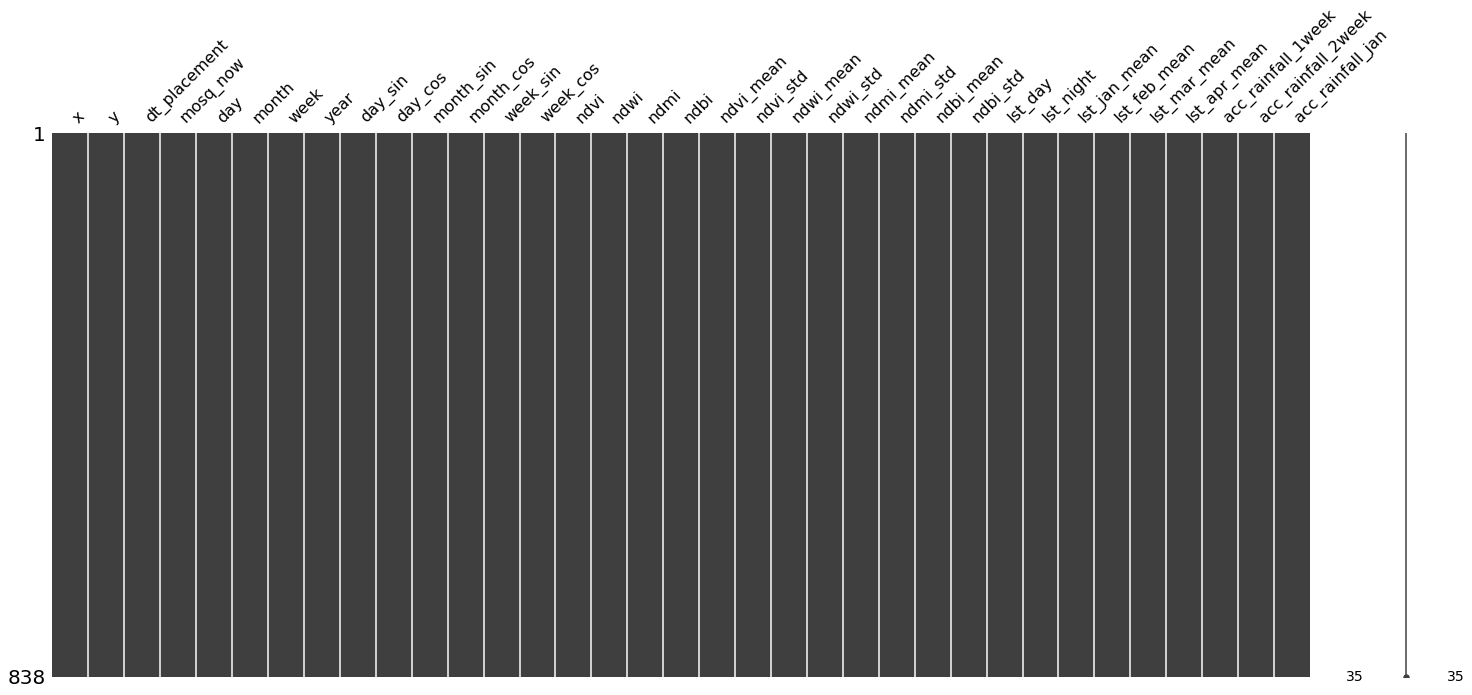

In [24]:
missingno.matrix(mosquito_data_nuts2)

In [25]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [26]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   16.5 155.3]


f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Mamoth Modules\Initializer_Module.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1.loc[:,'mosq_bins(t+1)'] =  culex
f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Mamoth Modules\Initializer_Module.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1.loc[:,'mosq_bins(t+1)'] =  culex
f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Mamoth Modules\Initializer_Module.py:151: SettingWithCopyWar

In [27]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 41.89980 | Val Loss: 32.63457 | Train Acc: 4.471| Val Acc: 4.113
Epoch 002: | Train Loss: 37.74914 | Val Loss: 31.42315 | Train Acc: 3.699| Val Acc: 3.884
Epoch 003: | Train Loss: 35.58188 | Val Loss: 28.73279 | Train Acc: 3.209| Val Acc: 3.395
Epoch 004: | Train Loss: 34.94710 | Val Loss: 27.00916 | Train Acc: 3.053| Val Acc: 3.178
Epoch 005: | Train Loss: 34.19113 | Val Loss: 25.06868 | Train Acc: 2.956| Val Acc: 2.572
Epoch 006: | Train Loss: 33.56696 | Val Loss: 23.91486 | Train Acc: 2.831| Val Acc: 2.117
Epoch 007: | Train Loss: 33.12950 | Val Loss: 23.52990 | Train Acc: 2.724| Val Acc: 2.051
Epoch 008: | Train Loss: 33.10318 | Val Loss: 23.35828 | Train Acc: 2.721| Val Acc: 2.033
Epoch 009: | Train Loss: 32.70038 | Val Loss: 23.51753 | Train Acc: 2.691| Val Acc: 1.793
Epoch 010: | Train Loss: 32.79870 | Val Loss: 23.66243 | Train Acc: 2.688| Val Acc: 1.983
Epoch 011: | Train Loss: 32.66436 | Val Loss: 23.68801 | Train Acc: 2.578| Val Acc: 1.975
Epoch 012:

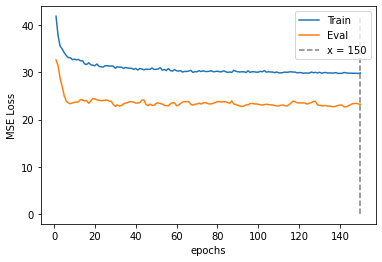

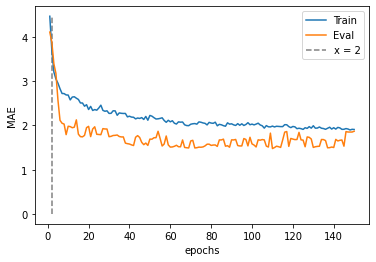

In [28]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [29]:
metrics(train, test, threshold=30)

MAE on train set:  21.78281401945023
min prediction: 1
max prediction: 199

MAE on test set:  26.19160325951064
Error ⩽ 30: 67.94 %
min prediction: 1
max prediction: 217


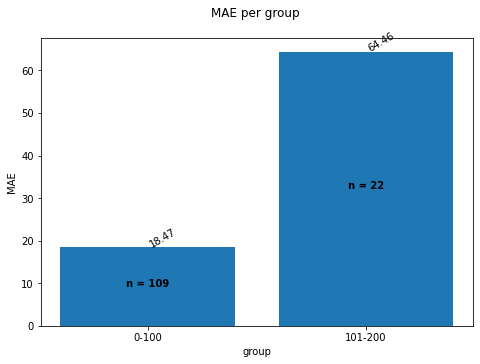

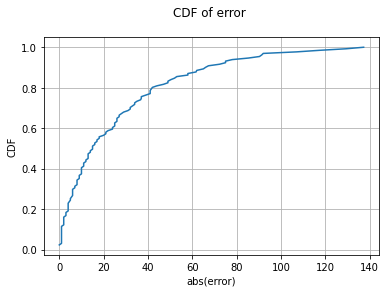

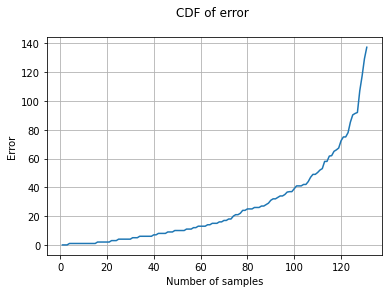

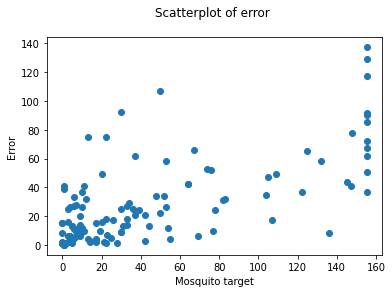

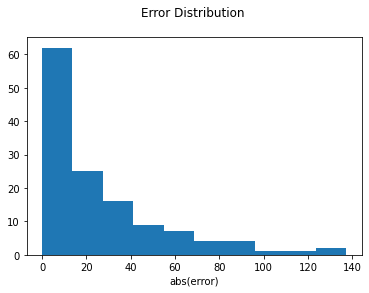

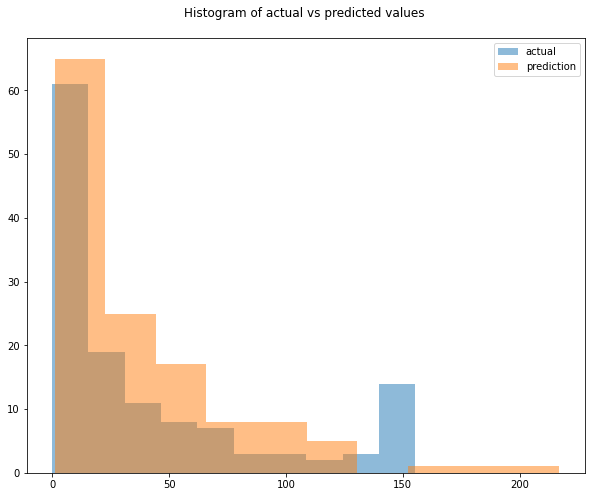

In [30]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.69533 | Val Loss: 0.04083 | Train Acc: 2.394| Val Acc: 0.045
Epoch 002: | Train Loss: 33.65913 | Val Loss: 0.27290 | Train Acc: 2.299| Val Acc: 0.955
Epoch 003: | Train Loss: 32.83641 | Val Loss: 0.39584 | Train Acc: 2.248| Val Acc: 0.955
Epoch 004: | Train Loss: 32.88412 | Val Loss: 0.55826 | Train Acc: 2.231| Val Acc: 0.955
Epoch 005: | Train Loss: 32.42400 | Val Loss: 0.49009 | Train Acc: 2.173| Val Acc: 0.955
Epoch 006: | Train Loss: 32.38362 | Val Loss: 0.40713 | Train Acc: 2.142| Val Acc: 0.955
Epoch 007: | Train Loss: 32.72633 | Val Loss: 0.60927 | Train Acc: 2.131| Val Acc: 0.955
Epoch 008: | Train Loss: 32.42200 | Val Loss: 0.39838 | Train Acc: 2.157| Val Acc: 0.955
Epoch 009: | Train Loss: 32.45853 | Val Loss: 0.14756 | Train Acc: 2.139| Val Acc: 0.045
Epoch 010: | Train Loss: 32.25569 | Val Loss: 0.09049 | Train Acc: 2.116| Val Acc: 0.045
Epoch 011: | Train Loss: 32.35217 | Val Loss: 0.10507 | Train Acc: 2.117| Val Acc: 0.045
Epoch 012: | Train Lo

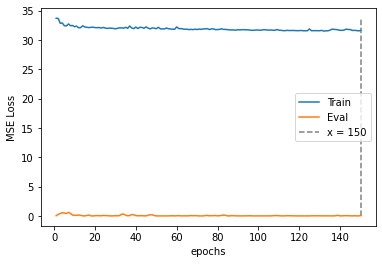

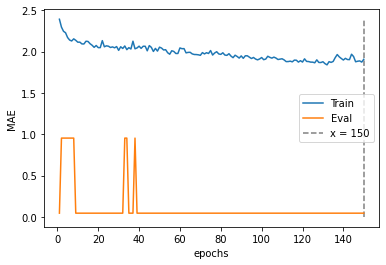

In [31]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [32]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [33]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [34]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [35]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [36]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [37]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

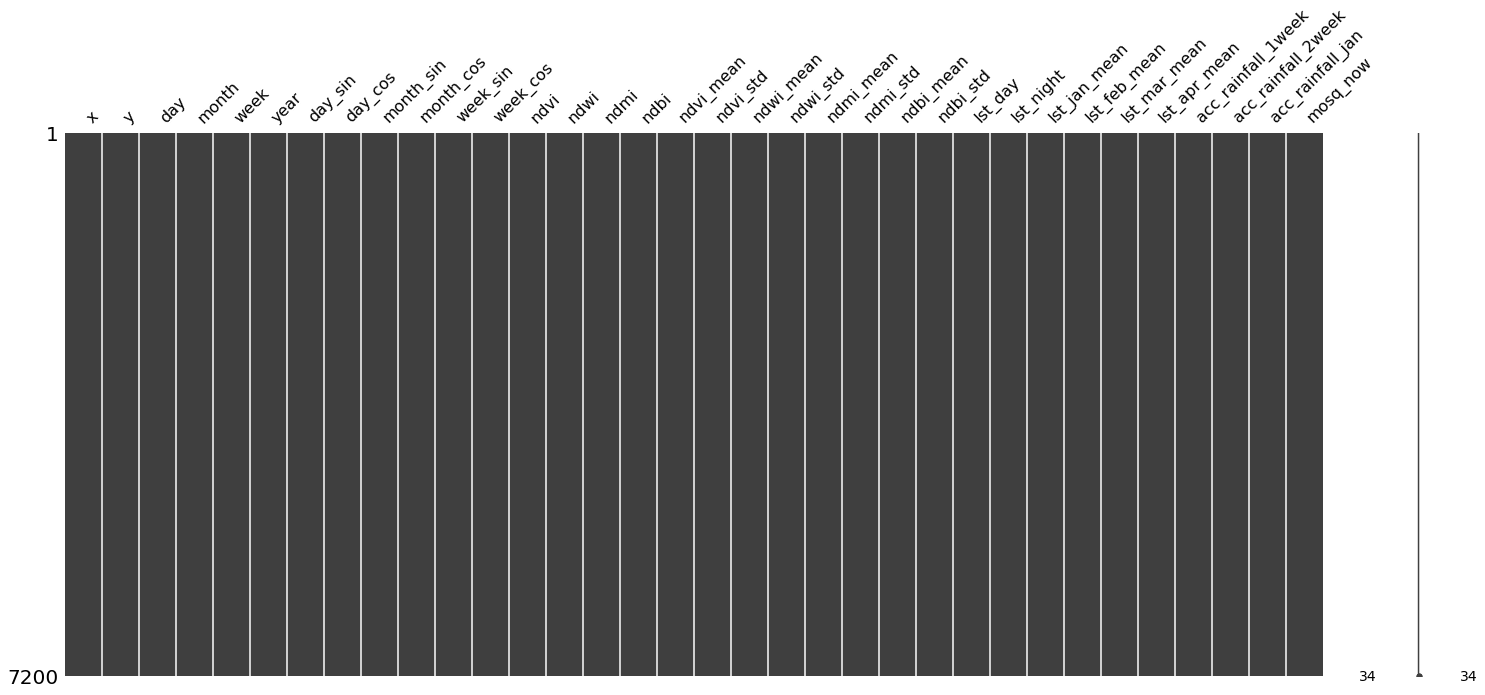

In [38]:
missingno.matrix(dataset_mamoth)

In [39]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [40]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [41]:
predictions = give_predictions(model, dataset_mamoth)

In [42]:
mosqutio_predictions['mosq_pred'] = predictions

In [43]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2010-01-01,8
1,22.692366,39.136391,2010-01-01,1
2,24.073790,39.328960,2010-01-01,1
3,21.430513,39.221380,2010-01-01,12
4,22.883800,39.351977,2010-01-01,1
...,...,...,...,...
7195,22.553160,39.852112,2021-12-16,59
7196,21.797560,39.635058,2021-12-16,36
7197,22.343000,39.828472,2021-12-16,12
7198,22.020557,39.603750,2021-12-16,49


In [44]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2021.csv', index = False)